import the data

In [1]:
import os
from torchvision import transforms
from PIL import Image
from pathlib import Path
import random
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import transforms
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/Dataset'
healthy_path = os.path.join(dataset_path, 'Healthy')
autism_path = os.path.join(dataset_path, 'Autistic')
ndd_path = os.path.join(dataset_path, 'NDD')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import random
from collections import defaultdict
from tqdm import tqdm
import torch
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

random.seed(42)

# preprocessing
preprocess_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# augmentation (for training data only)
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

data = []

# Load data
label_mapping = {
    'Healthy': 0,
    'Autistic': 1,
    'NDD': 2
}

for label_name, label in label_mapping.items():
    folder_path = os.path.join(dataset_path, label_name)
    for image_file in os.listdir(folder_path):
        data.append((os.path.join(folder_path, image_file), label))

# Organize data by class
class_data = defaultdict(list)
for image_path, label in data:
    class_data[label].append((image_path, label))

train_data, val_data, test_data = [], [], []

# Define split ratios
train_ratio = 0.70  # 70% of total dataset
test_ratio = 0.15   # 15% of total dataset
val_ratio = 0.15    # 15% of total dataset

# Split each class separately
for label, images in class_data.items():
    train, temp = train_test_split(
        images, test_size=(test_ratio + val_ratio), random_state=42, stratify=[label] * len(images)
    )
    test, val = train_test_split(
        temp, test_size=0.50, random_state=42, stratify=[label] * len(temp)  # 50% to each
    )

    train_data.extend(train)
    val_data.extend(val)  # Unseen data
    test_data.extend(test)  # Unseen data

# Print initial dataset counts before augmentation
print(f"Before augmentation:\nTotal training images: {len(train_data)}")
print(f"Total validation images: {len(val_data)}")
print(f"Total test images: {len(test_data)}")

# Apply augmentations only on the training data
augmented_train_data = []

for image_path, label in tqdm(train_data, desc="Processing training images", unit="image"):
    image = Image.open(image_path).convert("RGB")  # Ensure image is in RGB format

    # Apply augmentation to training images
    augmented_image = augmentation_transforms(image)

    # Convert both original and augmented images to tensors
    image_tensor = preprocess_transforms(image)
    augmented_image_tensor = preprocess_transforms(augmented_image)

    augmented_train_data.append((image_tensor, label))  # Original preprocessed image
    augmented_train_data.append((augmented_image_tensor, label))  # Augmented image

# For validation and test data, only apply preprocessing (no augmentation)
augmented_val_data = []
augmented_test_data = []

for image_path, label in val_data:
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess_transforms(image)
    augmented_val_data.append((image_tensor, label))

for image_path, label in test_data:
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess_transforms(image)
    augmented_test_data.append((image_tensor, label))

# Print dataset counts after augmentation
print(f"\nAfter augmentation:\nTotal training images: {len(augmented_train_data)}")
print(f"Total validation images: {len(augmented_val_data)}")
print(f"Total test images: {len(augmented_test_data)}")

# Shuffle the training data
random.shuffle(augmented_train_data)

# Convert to TensorDataset
train_data = torch.utils.data.TensorDataset(
    torch.stack([item[0] for item in augmented_train_data]),
    torch.tensor([item[1] for item in augmented_train_data])
)

val_data = torch.utils.data.TensorDataset(
    torch.stack([item[0] for item in augmented_val_data]),
    torch.tensor([item[1] for item in augmented_val_data])
)

test_data = torch.utils.data.TensorDataset(
    torch.stack([item[0] for item in augmented_test_data]),
    torch.tensor([item[1] for item in augmented_test_data])
)

# Create DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


Before augmentation:
Total training images: 3087
Total validation images: 663
Total test images: 660


Processing training images: 100%|██████████| 3087/3087 [00:33<00:00, 91.03image/s] 



After augmentation:
Total training images: 6174
Total validation images: 663
Total test images: 660


In [7]:
import torch.nn as nn
import torch.optim as optim
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.optim import AdamW


# Load the pre-trained ConvNeXt tiny model
#model = convnext_tiny(pretrained=True)
model = convnext_tiny(weights="ConvNeXt_Tiny_Weights.IMAGENET1K_V1")
num_classes = len(label_mapping)


#Dropout
# in_features = model.classifier[2].in_features  # This should be 768
model.classifier[2] = nn.Sequential(
    nn.Linear(model.classifier[2].in_features, 512),  # First FC layer
    nn.ReLU(),  # Activation function
    nn.Dropout(p=0.5),  # Dropout layer (50% dropout rate)
    nn.Linear(512, num_classes)  # Output layer
)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


# Learning rate scheduler
#optimizer = optim.Adam(model.parameters(), lr=0.0001)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=2e-4)


# Learning rate scheduler
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.1, patience=1, min_lr=1e-6, verbose=True)



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


train

Epoch 1/10
Train Loss: 0.5828, Train Accuracy: 0.8196
Val Loss: 0.4763, Val Accuracy: 0.8959
Epoch 2/10
Train Loss: 0.3812, Train Accuracy: 0.9569
Val Loss: 0.5207, Val Accuracy: 0.8748
Epoch 3/10
Train Loss: 0.3315, Train Accuracy: 0.9823
Val Loss: 0.4866, Val Accuracy: 0.8989
Epoch 4/10
Train Loss: 0.3034, Train Accuracy: 0.9984
Val Loss: 0.4721, Val Accuracy: 0.9125
Epoch 5/10
Train Loss: 0.3005, Train Accuracy: 0.9989
Val Loss: 0.4730, Val Accuracy: 0.9125
Epoch 6/10
Train Loss: 0.2992, Train Accuracy: 0.9992
Val Loss: 0.4693, Val Accuracy: 0.9125
Epoch 7/10
Train Loss: 0.2987, Train Accuracy: 0.9994
Val Loss: 0.4671, Val Accuracy: 0.9186
Epoch 8/10
Train Loss: 0.2984, Train Accuracy: 0.9997
Val Loss: 0.4659, Val Accuracy: 0.9170
Epoch 9/10
Train Loss: 0.2975, Train Accuracy: 0.9997
Val Loss: 0.4701, Val Accuracy: 0.9170
Epoch 10/10
Train Loss: 0.2974, Train Accuracy: 0.9998
Val Loss: 0.4727, Val Accuracy: 0.9186


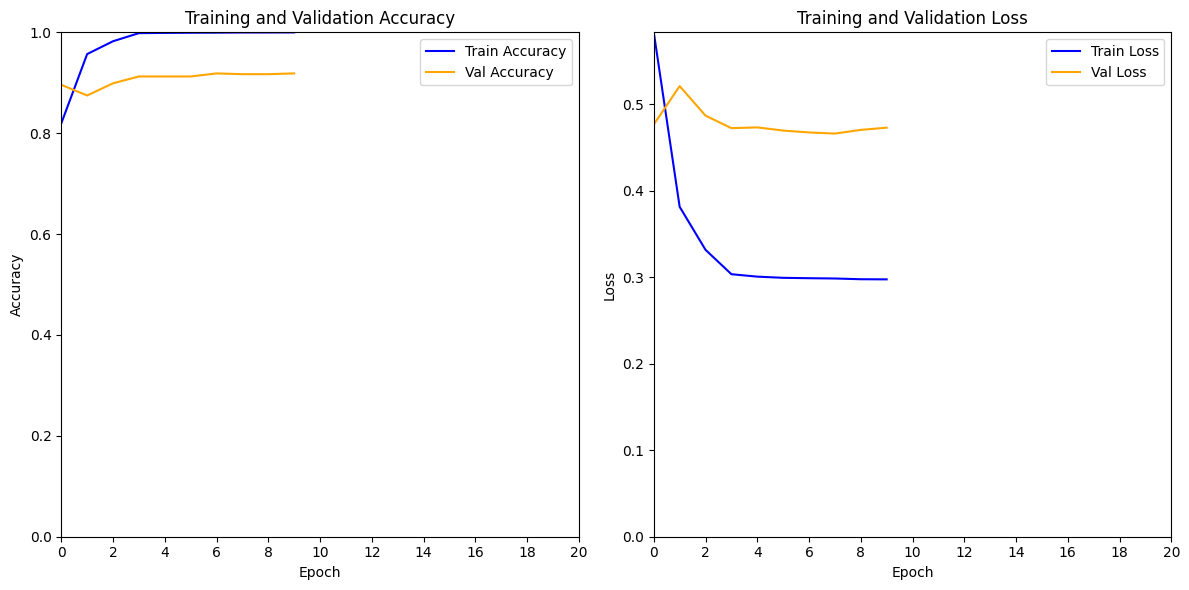

In [8]:
import matplotlib.pyplot as plt
import numpy as np
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, patience=5):
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_without_improvement = 0

    # To store accuracy and loss for plotting
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

        # Save the metrics for plotting
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss or val_acc > best_val_acc:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping...")
                break

    # Plot the accuracies and losses after training
    plt.figure(figsize=(12, 6))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Train Accuracy', color='blue')
    plt.plot(val_accuracies, label='Val Accuracy', color='orange')
    plt.xticks(np.arange(0, 21, 2))  # Set x-ticks from 2 to 20 with step 2
    plt.xlim(0, 20)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='orange')
    plt.xticks(np.arange(0, 21, 2))  # Set x-ticks from 2 to 20 with step 2
    plt.xlim(0, 20)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim(0, max(max(train_losses), max(val_losses)))
    plt.legend()

    plt.tight_layout()
    plt.show()

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)


test

In [9]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {correct / total:.4f}")

test_model(model, test_loader)


Test Accuracy: 0.9030


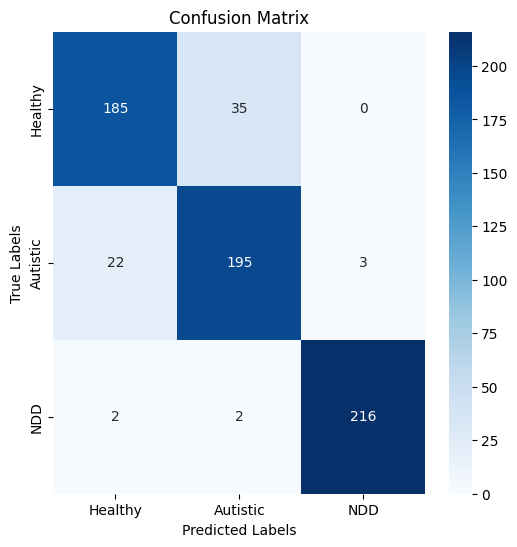

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.89      0.84      0.86       220
    Autistic       0.84      0.89      0.86       220
         NDD       0.99      0.98      0.98       220

    accuracy                           0.90       660
   macro avg       0.90      0.90      0.90       660
weighted avg       0.90      0.90      0.90       660



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


true_labels = []
predicted_labels = []

# Evaluate on the test set
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_mapping.keys()), yticklabels=list(label_mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report (Accuracy, Precision, Recall, F1-score)
report = classification_report(true_labels, predicted_labels, target_names=list(label_mapping.keys()))
print("Classification Report:")
print(report)


# **Visualization**

t-SNE

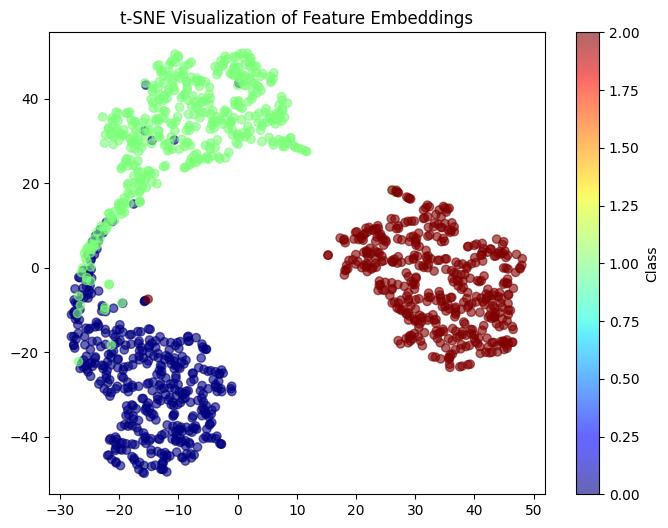

In [11]:
from sklearn.manifold import TSNE

# Extract feature embeddings from model
model.eval()
features = []
labels_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        features.append(outputs.cpu().numpy())
        labels_list.append(labels.cpu().numpy())

features = np.concatenate(features)
labels_list = np.concatenate(labels_list)

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d = tsne.fit_transform(features)

# Plot t-SNE scatter plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_list, cmap='jet', alpha=0.6)
plt.colorbar(scatter, label="Class")
plt.title("t-SNE Visualization of Feature Embeddings")
plt.show()


ROC curve

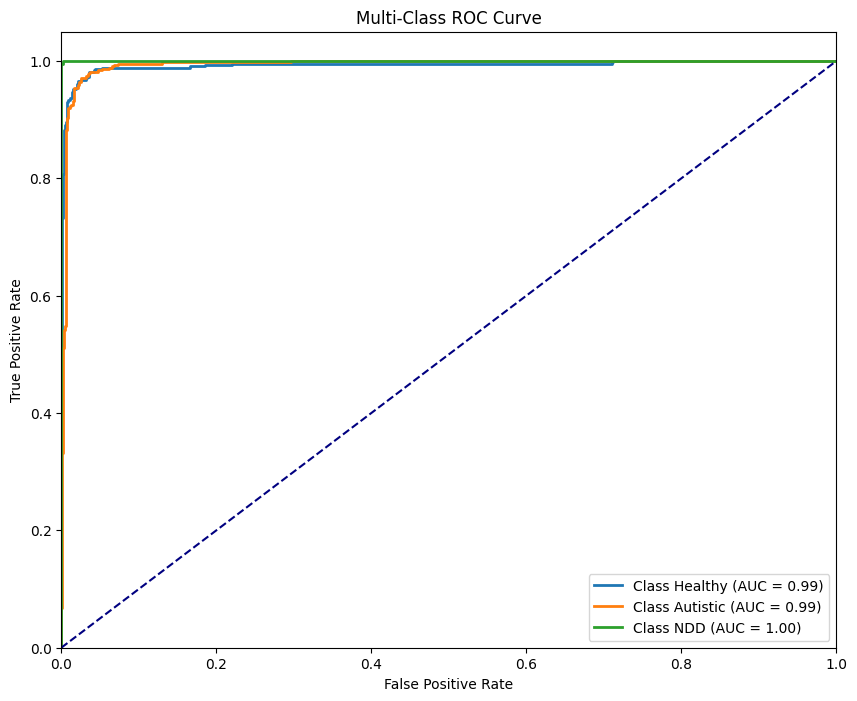

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Number of classes
num_classes = len(label_mapping)

# Store true labels and predicted probabilities
true_labels = []
predicted_probs = []

# Evaluate on the test set
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)  # Convert logits to probabilities

        true_labels.extend(labels.cpu().numpy())
        predicted_probs.extend(probs.cpu().numpy())

true_labels = np.array(true_labels)
predicted_probs = np.array(predicted_probs)

# Convert true labels to one-hot encoding
true_labels_one_hot = label_binarize(true_labels, classes=np.arange(num_classes))

# Compute ROC Curve and AUC for each class
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], predicted_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'Class {list(label_mapping.keys())[i]} (AUC = {roc_auc:.2f})')

# Plot diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.show()


top 3 classes

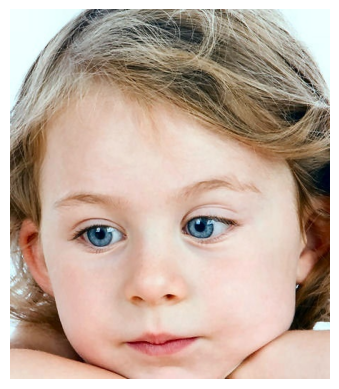

Top 3 Predictions:
Class: Autistic, Probability: 0.9456
Class: NDD, Probability: 0.0284
Class: Healthy, Probability: 0.0259


In [18]:
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
import torch
import torch.nn.functional as F

# Preprocessing function
def preprocess_image(image):
    """
    Preprocesses the image (resize, convert to RGB, tensor conversion, normalization).
    """
    image = image.convert("RGB")  # Convert to RGB
    image = image.resize((224, 224))  # Resize image to 224x224
    image = transforms.ToTensor()(image)  # Convert to tensor
    image = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(image)  # Normalize
    return image

# Function to predict top 3 classes for a given image
def predict_top_3_classes(image_path, model, label_mapping, device):
    # Preprocess the image
    image = Image.open(image_path)

    # Display the image
    plt.imshow(image)
    plt.axis('off')
    plt.show()

    # Preprocess image tensor
    image_tensor = preprocess_image(image).unsqueeze(0).to(device)

    # Forward pass through the model
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)  # Apply softmax to get probabilities

    # Get the top 3 class indices and their probabilities
    top3_probabilities, top3_indices = torch.topk(probabilities, 3, dim=1)

    # Map the indices to class names
    top3_classes = [list(label_mapping.keys())[i] for i in top3_indices[0]]

    # Print the top 3 predictions with their probabilities
    print("Top 3 Predictions:")
    for i in range(3):
        print(f"Class: {top3_classes[i]}, Probability: {top3_probabilities[0][i].item():.4f}")

image_path = '/content/drive/MyDrive/new-data-for-testing/Autism_test.jpg'
predict_top_3_classes(image_path, model, label_mapping, device)


XAI

# **k-cross**

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from sklearn.model_selection import KFold
from collections import Counter
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.optim import AdamW
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load augmented dataset
augmented_data = torch.load("/content/drive/MyDrive/rotation_and_flip.pt")
print(f"Loaded augmented dataset size: {len(augmented_data)}")

# Split the augmented data into images and labels
images = torch.stack([item[0] for item in augmented_data])
labels = torch.tensor([item[1] for item in augmented_data])

# K-fold Cross-validation setup
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True)

# Load pre-trained ConvNeXt model
model = convnext_tiny(weights="ConvNeXt_Tiny_Weights.IMAGENET1K_V1")
num_classes = 3  # Update with your number of classes

model.classifier[2] = nn.Sequential(
    nn.Linear(model.classifier[2].in_features, 512),  # First FC layer
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, num_classes)  # Output layer
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=0.0001, weight_decay=2e-4)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.1, patience=1, min_lr=1e-6, verbose=True
)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, patience=5):
    best_val_loss = float('inf')
    best_val_acc = 0.0
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = correct / total

        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

        if val_loss < best_val_loss or val_acc > best_val_acc:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping...")
                break

# K-fold cross-validation
for fold, (train_idx, val_idx) in enumerate(kf.split(images, labels)):
    print(f"Fold {fold + 1}/{k_folds}")

    # Prepare train and validation datasets for the current fold
    train_images, val_images = images[train_idx], images[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    # Create DataLoader instances for training and validation
    train_dataset = TensorDataset(train_images, train_labels)
    val_dataset = TensorDataset(val_images, val_labels)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

    # Train the model for the current fold
    train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)

    # Reset the model for the next fold
    model = convnext_tiny(weights="ConvNeXt_Tiny_Weights.IMAGENET1K_V1")
    model.classifier[2] = nn.Sequential(
        nn.Linear(model.classifier[2].in_features, 512),  # First FC layer
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(512, num_classes)
    )
    model = model.to(device)
    optimizer = AdamW(model.parameters(), lr=0.0001, weight_decay=2e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.1, patience=1, min_lr=1e-6, verbose=True
    )


# **new**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total images: 4410


Processing training images: 100%|██████████| 3087/3087 [01:10<00:00, 43.52image/s]
<ipython-input-3-7b3717e9a830>:101: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
<ipython-input-3-7b3717e9a830>:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



Epoch 1/10
Train Loss: 0.6711, Train Accuracy: 0.7690
Val Loss: 0.5228, Val Accuracy: 0.8563

Epoch 2/10
Train Loss: 0.4857, Train Accuracy: 0.8902
Val Loss: 0.5122, Val Accuracy: 0.8517

Epoch 3/10
Train Loss: 0.4101, Train Accuracy: 0.9351
Val Loss: 0.5701, Val Accuracy: 0.8578

Epoch 4/10
Train Loss: 0.3539, Train Accuracy: 0.9708
Val Loss: 0.6000, Val Accuracy: 0.8578

Epoch 5/10
Train Loss: 0.3261, Train Accuracy: 0.9862
Val Loss: 0.5869, Val Accuracy: 0.8638

Epoch 6/10
Train Loss: 0.3050, Train Accuracy: 0.9945
Val Loss: 0.5604, Val Accuracy: 0.8790

Epoch 7/10
Train Loss: 0.3007, Train Accuracy: 0.9969
Val Loss: 0.5539, Val Accuracy: 0.8911

Epoch 8/10
Train Loss: 0.3008, Train Accuracy: 0.9966
Val Loss: 0.5527, Val Accuracy: 0.8926

Epoch 9/10
Train Loss: 0.2975, Train Accuracy: 0.9987
Val Loss: 0.5577, Val Accuracy: 0.8911

Epoch 10/10
Train Loss: 0.2965, Train Accuracy: 0.9990
Val Loss: 0.5566, Val Accuracy: 0.8956


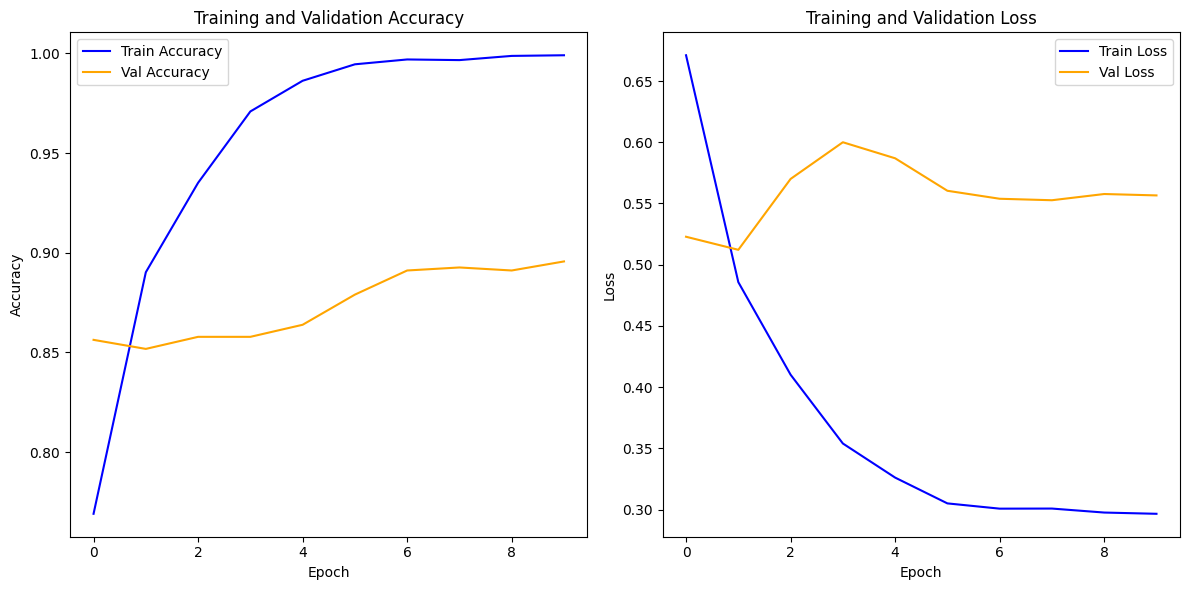

<ipython-input-3-7b3717e9a830>:196: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))


Test Accuracy: 90.94%


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import random
import torch
from torch import nn, optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset path (update this if needed)
dataset_path = '/content/drive/MyDrive/Dataset'
healthy_path = os.path.join(dataset_path, 'Healthy')
autism_path = os.path.join(dataset_path, 'Autistic')
ndd_path = os.path.join(dataset_path, 'NDD')

# Data transformations
preprocess_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02)
])

# Label mapping
label_mapping = {'Healthy': 0, 'Autistic': 1, 'NDD': 2}
data = []

for label_name, path in [('Healthy', healthy_path), ('Autistic', autism_path), ('NDD', ndd_path)]:
    for img in os.listdir(path):
        img_path = os.path.join(path, img)
        data.append((img_path, label_mapping[label_name]))

# Check dataset size
print(f"Total images: {len(data)}")

# Split dataset into train (70%), validation (15%), and test (15%)
train_ratio, val_ratio, test_ratio = 0.70, 0.15, 0.15
train_data, temp_data = train_test_split(data, test_size=(val_ratio + test_ratio), random_state=42, stratify=[label for _, label in data])
val_data, test_data = train_test_split(temp_data, test_size=0.50, random_state=42, stratify=[label for _, label in temp_data])

# Augment training data
augmented_train_data = []
for image_path, label in tqdm(train_data, desc="Processing training images", unit="image"):
    image = Image.open(image_path).convert("RGB")
    augmented_train_data.append((preprocess_transforms(image), label))  # Original
    augmented_train_data.append((preprocess_transforms(augmentation_transforms(image)), label))  # Augmented

# Convert validation and test data
def process_images(data):
    return [(preprocess_transforms(Image.open(image_path).convert("RGB")), label) for image_path, label in data]

val_data = process_images(val_data)
test_data = process_images(test_data)

# Convert to TensorDataset and DataLoader
def create_dataloader(data, batch_size=32, shuffle=True):
    images, labels = zip(*data)
    return DataLoader(TensorDataset(torch.stack(images), torch.tensor(labels)), batch_size=batch_size, shuffle=shuffle)

train_loader = create_dataloader(augmented_train_data)
val_loader = create_dataloader(val_data, shuffle=False)
test_loader = create_dataloader(test_data, shuffle=False)

# Load ConvNeXt Tiny model (pretrained on ImageNet)
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
model.classifier[2] = nn.Sequential(
    nn.Linear(model.classifier[2].in_features, 512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(512, len(label_mapping))
)
model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=2e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, patience=3):
    best_val_loss, best_val_acc, epochs_without_improvement = float('inf'), 0.0, 0
    scaler = torch.cuda.amp.GradScaler()

    train_accuracies, val_accuracies, train_losses, val_losses = [], [], [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Prevent exploding gradients
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total
        scheduler.step()

        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")

        # Save best model
        if val_loss < best_val_loss or val_acc > best_val_acc:
            best_val_loss, best_val_acc = val_loss, val_acc
            epochs_without_improvement = 0
            torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print("Early stopping...")
                break

        # Save metrics for plotting
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Plot accuracy and loss
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Train Accuracy', color='blue')
    plt.plot(val_accuracies, label='Val Accuracy', color='orange')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train Loss', color='blue')
    plt.plot(val_losses, label='Val Loss', color='orange')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)

# Load best model
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))

# Evaluate on test set
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")


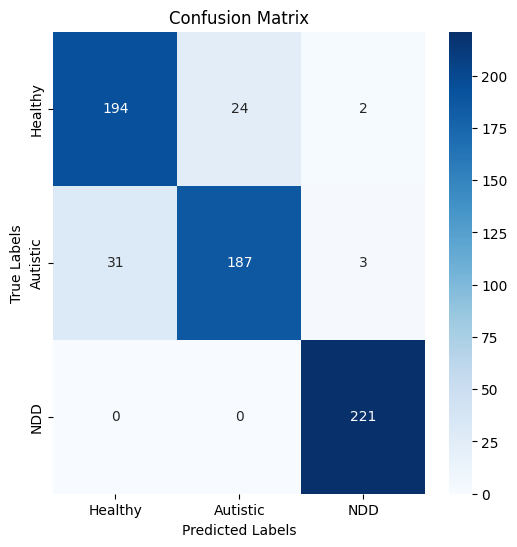

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.86      0.88      0.87       220
    Autistic       0.89      0.85      0.87       221
         NDD       0.98      1.00      0.99       221

    accuracy                           0.91       662
   macro avg       0.91      0.91      0.91       662
weighted avg       0.91      0.91      0.91       662



In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


true_labels = []
predicted_labels = []

# Evaluate on the test set
model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(label_mapping.keys()), yticklabels=list(label_mapping.keys()))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report (Accuracy, Precision, Recall, F1-score)
report = classification_report(true_labels, predicted_labels, target_names=list(label_mapping.keys()))
print("Classification Report:")
print(report)
